In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report)


In [11]:
from google.colab import files
uploaded = files.upload()



Saving Heart.csv to Heart (1).csv


In [12]:
data = pd.read_csv('Heart.csv')
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [13]:
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  num       303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB


In [15]:
data.shape

(303, 14)

In [16]:
data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


In [17]:
data.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
298,45,1,1,110,264,0,0,132,0,1.2,2,0.0,7.0,1
299,68,1,4,144,193,1,0,141,0,3.4,2,2.0,7.0,2
300,57,1,4,130,131,0,0,115,1,1.2,2,1.0,7.0,3
301,57,0,2,130,236,0,2,174,0,0.0,2,1.0,3.0,1
302,38,1,3,138,175,0,0,173,0,0.0,1,NaN,3.0,0


In [18]:
# 0 = No Disease
# 1 = Disease
data['target'] = data['num'].apply(lambda x: 0 if x == 0 else 1)
data['target'].value_counts()

,count
target,
0,164
1,139


In [19]:
 data.duplicated().sum()

np.int64(0)

In [20]:
data.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [21]:
for col in data.select_dtypes(include=['int64','float64']).columns:
    data[col]=data[col].fillna(data[col].median())
data.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


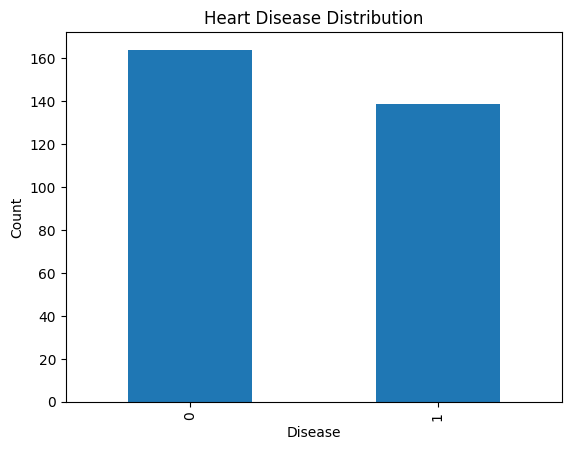

In [22]:
data['target'].value_counts().plot(kind='bar')
plt.title("Heart Disease Distribution")
plt.xlabel("Disease")
plt.ylabel("Count")
plt.show()

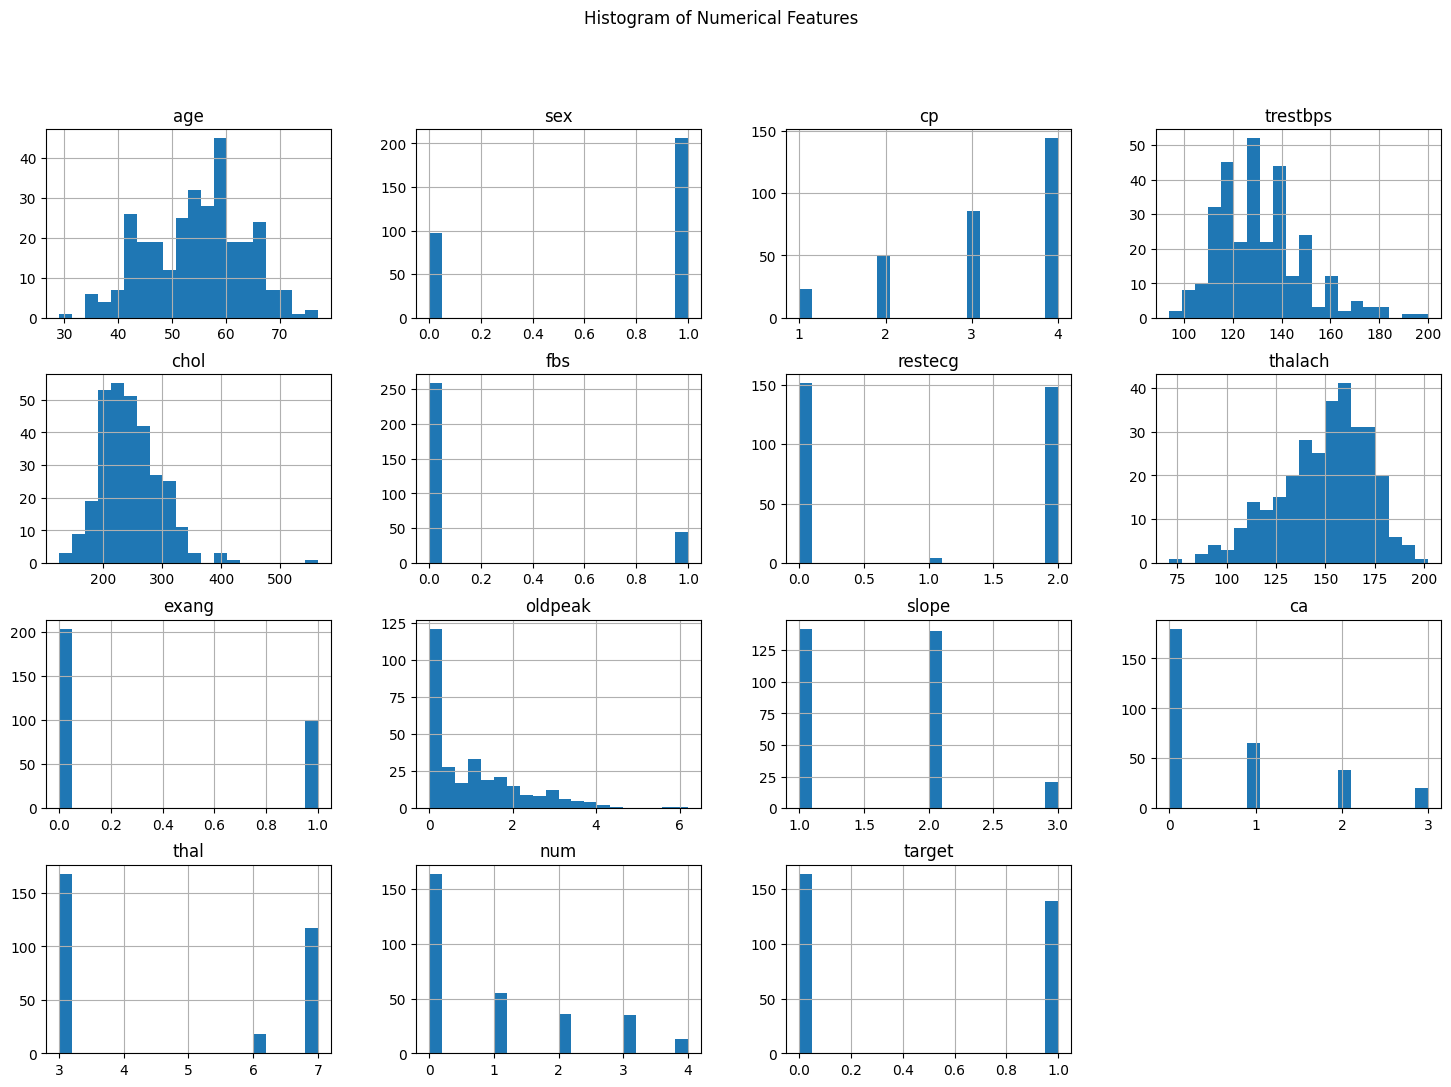

In [23]:
data.hist(figsize=(18,12), bins=20)
plt.suptitle("Histogram of Numerical Features")
plt.show()

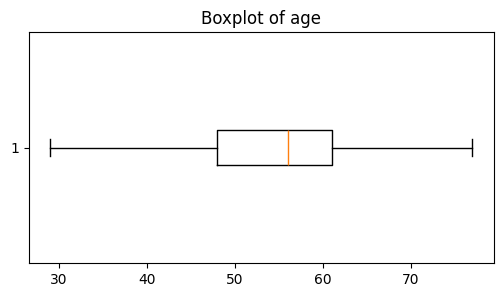

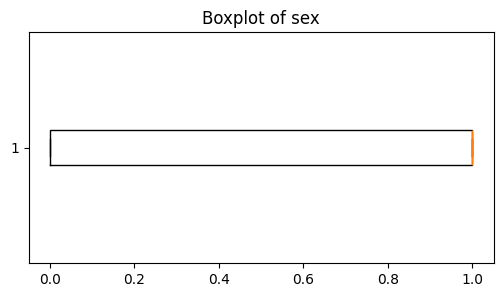

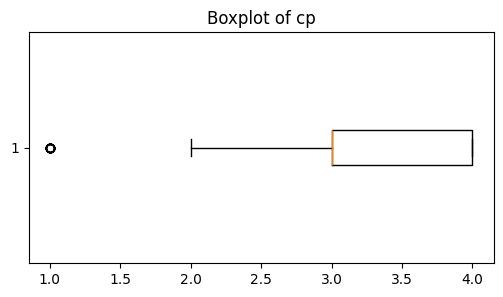

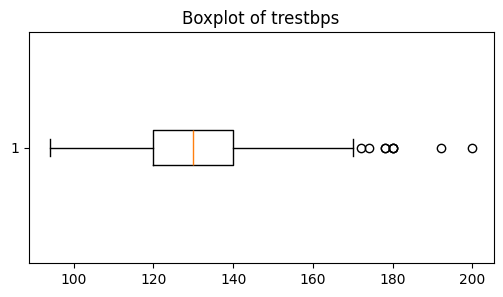

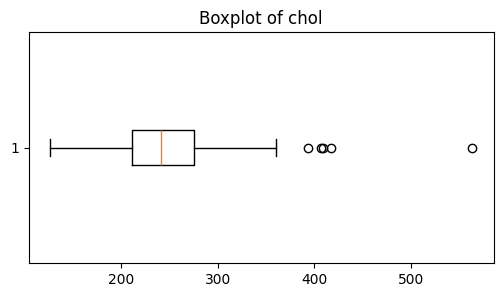

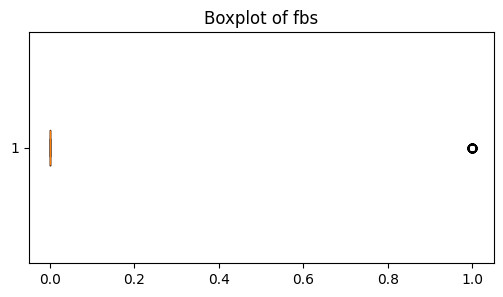

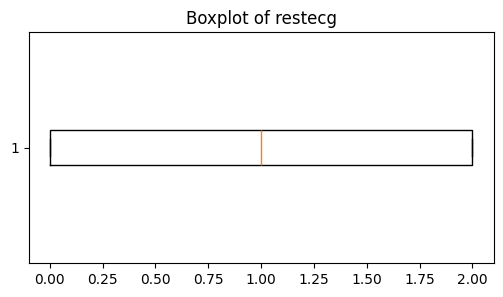

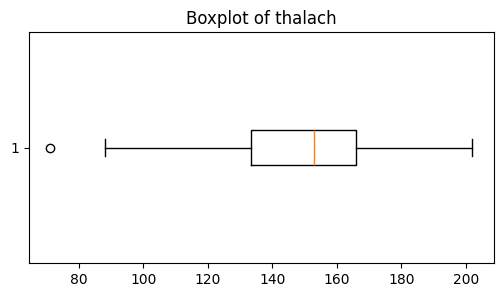

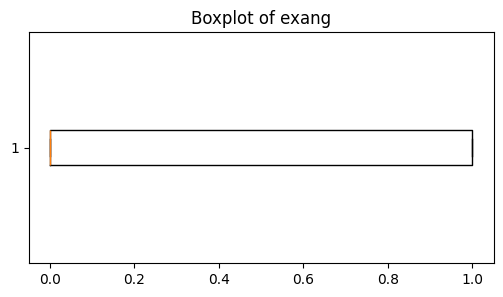

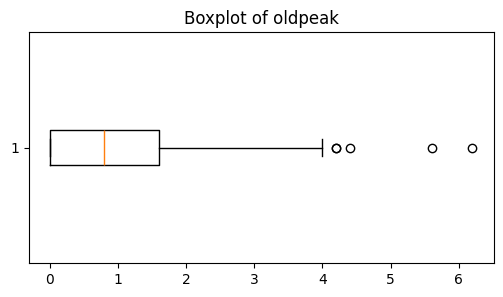

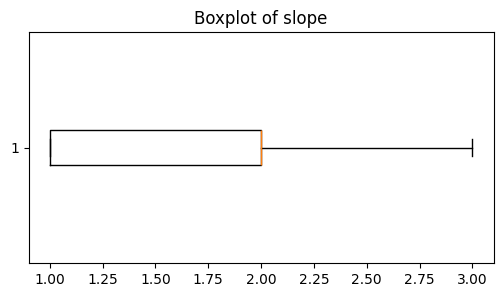

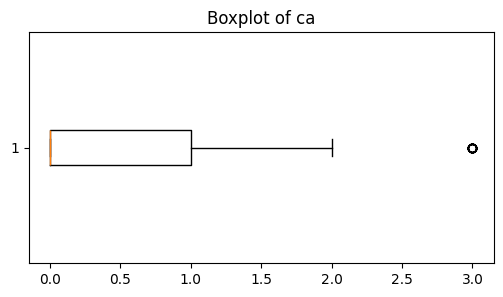

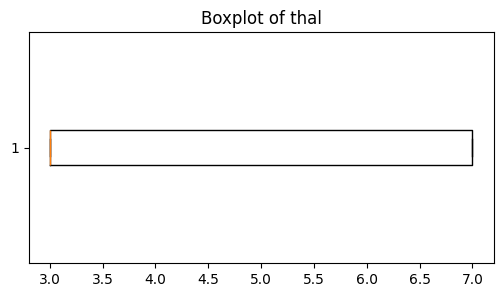

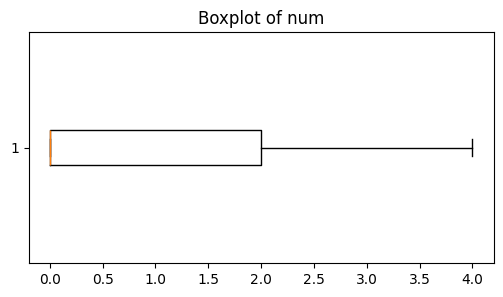

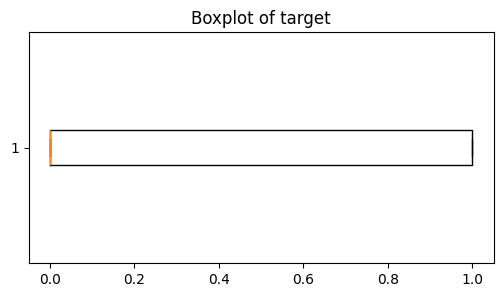

In [24]:
numerical_columns = data.select_dtypes(include=['int64','float64']).columns
for col in numerical_columns:
    plt.figure(figsize=(6,3))
    plt.boxplot(data[col], vert=False)
    plt.title(f"Boxplot of {col}")
    plt.show()

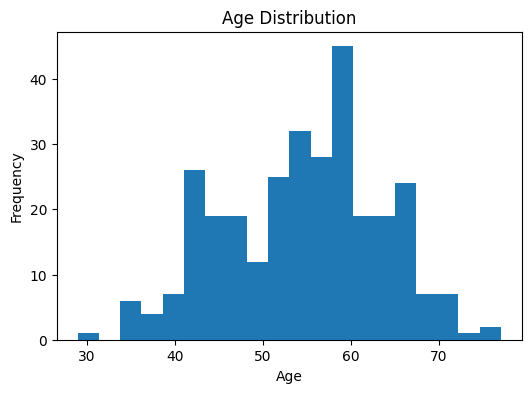

In [25]:
plt.figure(figsize=(6,4))
plt.hist(data['age'], bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

/tmp/ipykernel_2040/3433212746.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data[data['target']==0]['age'],


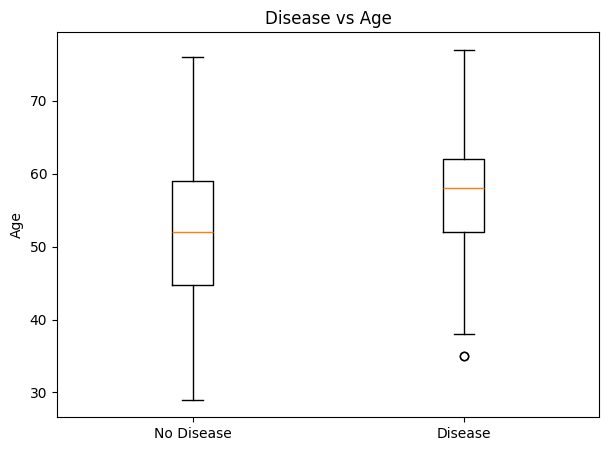

In [26]:
plt.figure(figsize=(7,5))
plt.boxplot([data[data['target']==0]['age'],
     data[data['target']==1]['age']],
    labels=['No Disease','Disease'])
plt.title("Disease vs Age")
plt.ylabel("Age")
plt.show()

/tmp/ipykernel_2040/628655152.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


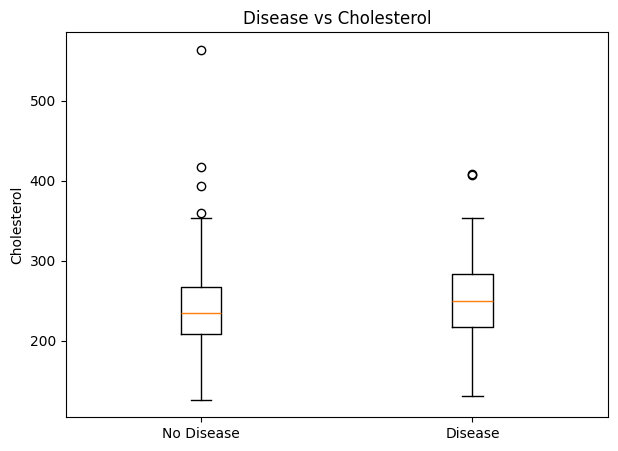

In [27]:
plt.figure(figsize=(7,5))
plt.boxplot(
    [data[data['target']==0]['chol'],
     data[data['target']==1]['chol']],
    labels=['No Disease','Disease'])
plt.title("Disease vs Cholesterol")
plt.ylabel("Cholesterol")
plt.show()

/tmp/ipykernel_2040/3923694277.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


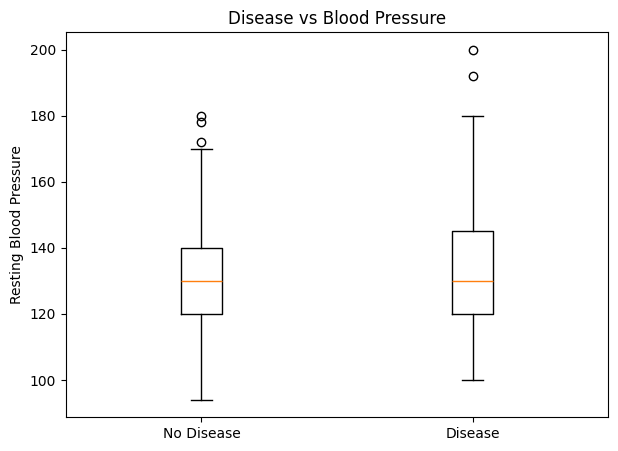

In [28]:
plt.figure(figsize=(7,5))
plt.boxplot(
    [data[data['target']==0]['trestbps'],
     data[data['target']==1]['trestbps']],
    labels=['No Disease','Disease'])
plt.title("Disease vs Blood Pressure")
plt.ylabel("Resting Blood Pressure")
plt.show()

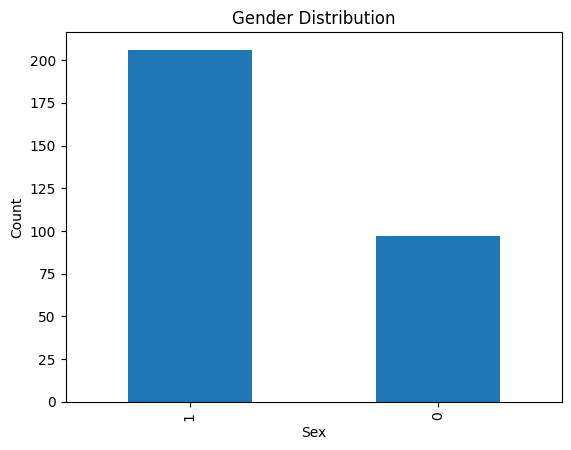

In [29]:
data['sex'].value_counts().plot(kind='bar')
plt.title("Gender Distribution")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.show()

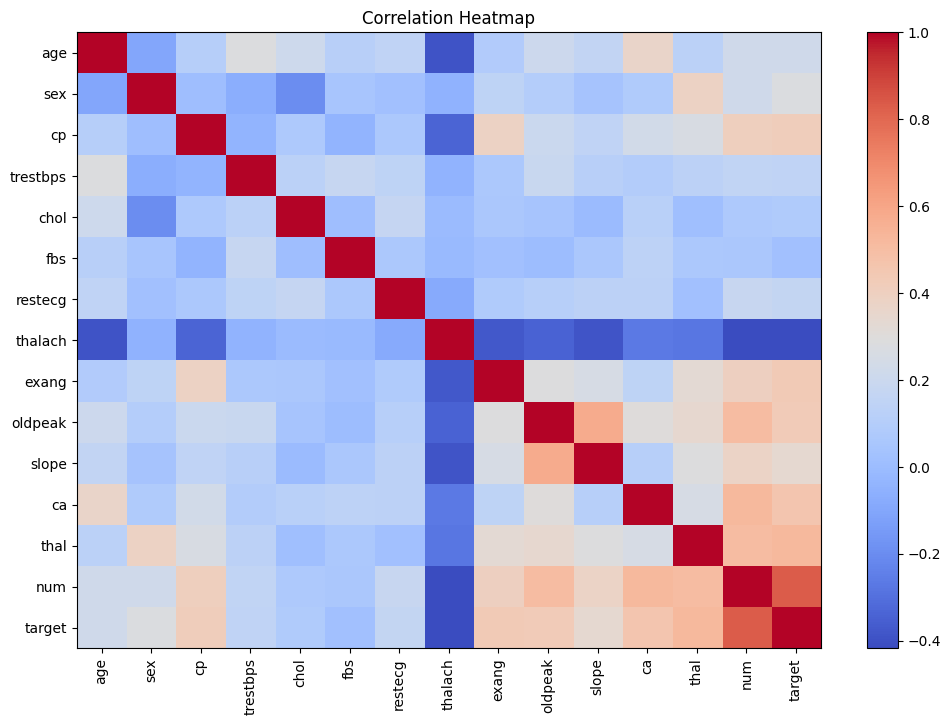

In [30]:
plt.figure(figsize=(12,8))
corr = data.corr()
plt.imshow(corr, cmap='coolwarm', aspect='auto')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")
plt.show()

In [31]:
# correlation with disease
data.corr(numeric_only=True)['target'].sort_values(ascending=False)

,target
target,1.000000
num,0.830081
thal,0.522057
ca,0.460033
exang,0.431894
oldpeak,0.424510
cp,0.414446
slope,0.339213
sex,0.276816
age,0.223120


In [32]:
# percentage of patients with disease
(data['target'].value_counts(normalize=True)*100).round(2)

,proportion
target,
0,54.13
1,45.87


In [33]:
# Create binary target
data['target'] = data['num'].apply(lambda x: 0 if x == 0 else 1)
# Drop original target column
data.drop('num', axis=1, inplace=True)
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [34]:
X = data.drop('target', axis=1)
y = data['target']
print(X.columns)

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal'],
      dtype='object')


In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [36]:
lr = LogisticRegression(random_state=42)
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)
lr_pred[:10]

array([0, 1, 0, 0, 1, 0, 0, 0, 1, 0])

In [37]:
print("Accuracy :", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred))
print("Recall   :", recall_score(y_test, lr_pred))
print("F1 Score :", f1_score(y_test, lr_pred))
print("ROC AUC  :", roc_auc_score(y_test, lr_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, lr_pred))

print("\nClassification Report")
print(classification_report(y_test, lr_pred))

Accuracy : 0.8688524590163934
Precision: 0.8125
Recall   : 0.9285714285714286
F1 Score : 0.8666666666666667
ROC AUC  : 0.8733766233766233

Confusion Matrix
[[27  6]
 [ 2 26]]

Classification Report
              precision    recall  f1-score   support

           0       0.93      0.82      0.87        33
           1       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61



In [38]:
svm = SVC(random_state=42)
svm.fit(X_train_scaled, y_train)
svm_pred = svm.predict(X_test_scaled)
svm_pred[:10]

array([0, 1, 0, 0, 1, 0, 0, 0, 1, 0])

In [39]:
print("Accuracy :", accuracy_score(y_test, svm_pred))
print("Precision:", precision_score(y_test, svm_pred))
print("Recall   :", recall_score(y_test, svm_pred))
print("F1 Score :", f1_score(y_test, svm_pred))
print("ROC AUC  :", roc_auc_score(y_test, svm_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, svm_pred))

print("\nClassification Report")
print(classification_report(y_test, svm_pred))

Accuracy : 0.8524590163934426
Precision: 0.8064516129032258
Recall   : 0.8928571428571429
F1 Score : 0.847457627118644
ROC AUC  : 0.8555194805194805

Confusion Matrix
[[27  6]
 [ 3 25]]

Classification Report
              precision    recall  f1-score   support

           0       0.90      0.82      0.86        33
           1       0.81      0.89      0.85        28

    accuracy                           0.85        61
   macro avg       0.85      0.86      0.85        61
weighted avg       0.86      0.85      0.85        61



In [40]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
dt_pred[:10]

array([0, 1, 0, 0, 0, 0, 1, 0, 1, 0])

In [41]:
print("Accuracy :", accuracy_score(y_test, dt_pred))
print("Precision:", precision_score(y_test, dt_pred))
print("Recall   :", recall_score(y_test, dt_pred))
print("F1 Score :", f1_score(y_test, dt_pred))
print("ROC AUC  :", roc_auc_score(y_test, dt_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, dt_pred))

print("\nClassification Report")
print(classification_report(y_test, dt_pred))

Accuracy : 0.7377049180327869
Precision: 0.6764705882352942
Recall   : 0.8214285714285714
F1 Score : 0.7419354838709677
ROC AUC  : 0.7440476190476191

Confusion Matrix
[[22 11]
 [ 5 23]]

Classification Report
              precision    recall  f1-score   support

           0       0.81      0.67      0.73        33
           1       0.68      0.82      0.74        28

    accuracy                           0.74        61
   macro avg       0.75      0.74      0.74        61
weighted avg       0.75      0.74      0.74        61



In [42]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_pred[:10]

array([0, 1, 0, 0, 0, 0, 0, 0, 1, 0])

In [43]:
print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))
print("ROC AUC  :", roc_auc_score(y_test, rf_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, rf_pred))

print("\nClassification Report")
print(classification_report(y_test, rf_pred))

Accuracy : 0.8852459016393442
Precision: 0.8387096774193549
Recall   : 0.9285714285714286
F1 Score : 0.8813559322033898
ROC AUC  : 0.8885281385281386

Confusion Matrix
[[28  5]
 [ 2 26]]

Classification Report
              precision    recall  f1-score   support

           0       0.93      0.85      0.89        33
           1       0.84      0.93      0.88        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.89      0.89      0.89        61



In [44]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss')
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
xgb_pred[:10]

array([1, 1, 0, 0, 0, 0, 0, 0, 1, 0])

In [45]:
print("Accuracy :", accuracy_score(y_test, xgb_pred))
print("Precision:", precision_score(y_test, xgb_pred))
print("Recall   :", recall_score(y_test, xgb_pred))
print("F1 Score :", f1_score(y_test, xgb_pred))
print("ROC AUC  :", roc_auc_score(y_test, xgb_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, xgb_pred))

print("\nClassification Report")
print(classification_report(y_test, xgb_pred))

Accuracy : 0.8524590163934426
Precision: 0.7878787878787878
Recall   : 0.9285714285714286
F1 Score : 0.8524590163934426
ROC AUC  : 0.8582251082251082

Confusion Matrix
[[26  7]
 [ 2 26]]

Classification Report
              precision    recall  f1-score   support

           0       0.93      0.79      0.85        33
           1       0.79      0.93      0.85        28

    accuracy                           0.85        61
   macro avg       0.86      0.86      0.85        61
weighted avg       0.86      0.85      0.85        61



In [46]:
results = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "SVM",
        "Decision Tree",
        "Random Forest",
        "XGBoost"],
    "Accuracy":[
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, svm_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)],
    "Precision":[
        precision_score(y_test, lr_pred),
        precision_score(y_test, svm_pred),
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, xgb_pred)],
    "Recall":[
        recall_score(y_test, lr_pred),
        recall_score(y_test, svm_pred),
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, xgb_pred)],
    "F1 Score":[
        f1_score(y_test, lr_pred),
        f1_score(y_test, svm_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, xgb_pred)],
    "ROC AUC":[
        roc_auc_score(y_test, lr_pred),
        roc_auc_score(y_test, svm_pred),
        roc_auc_score(y_test, dt_pred),
        roc_auc_score(y_test, rf_pred),
        roc_auc_score(y_test, xgb_pred)]})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.868852,0.812500,0.928571,0.866667,0.873377
1,SVM,0.852459,0.806452,0.892857,0.847458,0.855519
2,Decision Tree,0.737705,0.676471,0.821429,0.741935,0.744048
3,Random Forest,0.885246,0.838710,0.928571,0.881356,0.888528
4,XGBoost,0.852459,0.787879,0.928571,0.852459,0.858225


In [47]:
# Best Model is RandomForest
cm = confusion_matrix(y_test, rf_pred)
print(cm)

[[28  5]
 [ 2 26]]


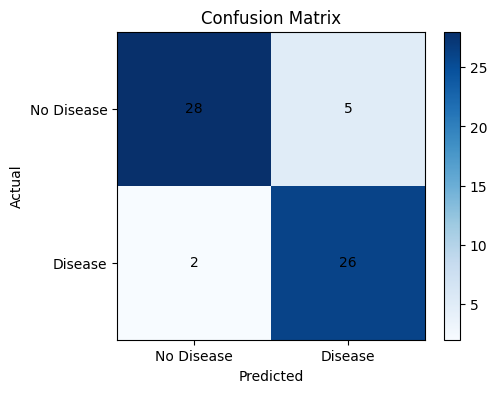

In [48]:
plt.figure(figsize=(5,4))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.xticks([0,1], ['No Disease','Disease'])
plt.yticks([0,1], ['No Disease','Disease'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.show()

In [51]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.93      0.85      0.89        33
           1       0.84      0.93      0.88        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.89      0.89      0.89        61



Feature Importance

In [52]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False)
print(feature_importance)

     Feature  Importance
7    thalach    0.135404
2         cp    0.127163
12      thal    0.122940
11        ca    0.100811
0        age    0.091327
9    oldpeak    0.089358
4       chol    0.088681
3   trestbps    0.080716
8      exang    0.050730
10     slope    0.046626
1        sex    0.035947
6    restecg    0.018389
5        fbs    0.011908


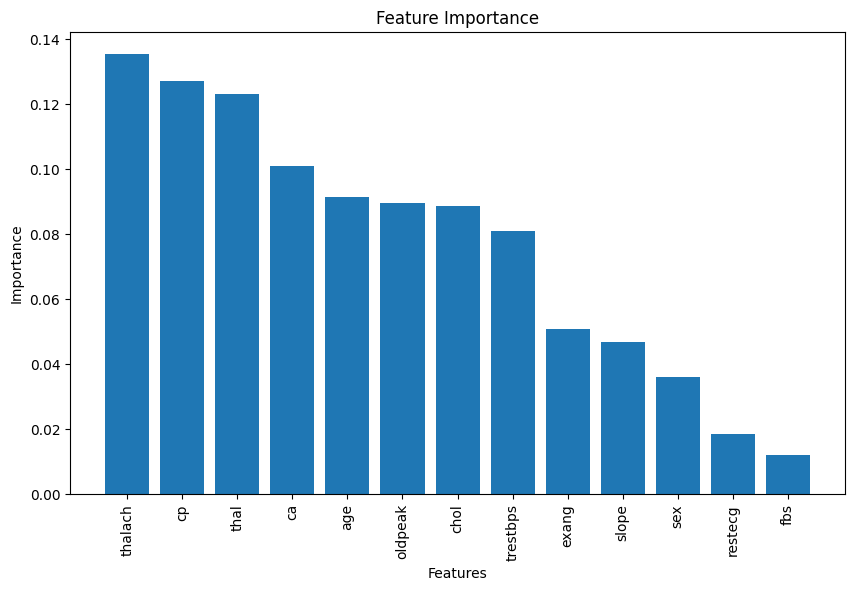

In [53]:
plt.figure(figsize=(10,6))  # Plot Feature Importance
plt.bar(feature_importance['Feature'],
        feature_importance['Importance'])
plt.xticks(rotation=90)
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

In [54]:
import joblib
joblib.dump(rf, "heart_disease_random_forest.pkl")
print("Model Saved Successfully")

Model Saved Successfully
